In [ ]:
import json
import os
import pickle
import warnings
from pathlib import Path
import matplotlib.pyplot as plt
import neurokit2 as nk
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.signal import butter, filtfilt, find_peaks
from tqdm import tqdm
from sklearn.ensemble import (
    GradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from xgboost import XGBClassifier
warnings.filterwarnings("ignore")

In [ ]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
DATA_ROOT = Path("../data/processed")  
RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(exist_ok=True)
ALL_SUBJECTS = [s for s in range(2, 18) if s != 12]  
print(f"Subjects: {ALL_SUBJECTS}")
print(f"Total subjects: {len(ALL_SUBJECTS)}")
FS = 700         
WINDOW_SEC = 30   
WINDOW_SAMPLES = FS * WINDOW_SEC  
MODALITY_NAMES = ['ECG', 'EDA', 'Respiration', 'Temperature']
MODALITY_IDX   = {name: i for i, name in enumerate(MODALITY_NAMES)}

Subjects: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 16, 17]
Total subjects: 15


In [ ]:
def load_subject(sid):
    X = np.load(DATA_ROOT / f"S{sid}_X.npy")
    y = np.load(DATA_ROOT / f"S{sid}_y.npy")
    return X, y

def load_all_except(test_sid):
    X_list, y_list = [], []
    for sid in ALL_SUBJECTS:
        if sid == test_sid:
            continue
        X, y = load_subject(sid)
        X_list.append(X)
        y_list.append(y)
    return np.concatenate(X_list, axis=0), np.concatenate(y_list, axis=0)

In [ ]:
print("Checking all subject files...")
for sid in ALL_SUBJECTS:
    X, y = load_subject(sid)
    n_stress = y.sum()
    n_total  = len(y)
    stress_pct = 100 * n_stress / n_total
    print(f"  S{sid:2d}: X={X.shape}, y={y.shape}, stress={n_stress}/{n_total} ({stress_pct:.1f}%)")
    assert X.shape[1] == 4,         f"S{sid}: expected 4 modalities, got {X.shape[1]}"
    assert X.shape[2] == WINDOW_SAMPLES, f"S{sid}: expected {WINDOW_SAMPLES} samples/window"
    assert not np.any(np.isnan(X)), f"S{sid}: NaN values found in X"
print("\nAll files OK.")

Checking all subject files...
  S 2: X=(140, 4, 21000), y=(140,), stress=41/140 (29.3%)
  S 3: X=(142, 4, 21000), y=(142,), stress=42/142 (29.6%)
  S 4: X=(143, 4, 21000), y=(143,), stress=41/143 (28.7%)
  S 5: X=(146, 4, 21000), y=(146,), stress=42/146 (28.8%)
  S 6: X=(145, 4, 21000), y=(145,), stress=43/145 (29.7%)
  S 7: X=(145, 4, 21000), y=(145,), stress=42/145 (29.0%)
  S 8: X=(146, 4, 21000), y=(146,), stress=44/146 (30.1%)
  S 9: X=(145, 4, 21000), y=(145,), stress=43/145 (29.7%)
  S10: X=(150, 4, 21000), y=(150,), stress=47/150 (31.3%)
  S11: X=(147, 4, 21000), y=(147,), stress=45/147 (30.6%)
  S13: X=(147, 4, 21000), y=(147,), stress=43/147 (29.3%)
  S14: X=(147, 4, 21000), y=(147,), stress=45/147 (30.6%)
  S15: X=(147, 4, 21000), y=(147,), stress=44/147 (29.9%)
  S16: X=(147, 4, 21000), y=(147,), stress=45/147 (30.6%)
  S17: X=(150, 4, 21000), y=(150,), stress=47/150 (31.3%)

All files OK.


In [ ]:
def extract_ecg_features(ecg_window, fs=FS):
    try:
        signals, info = nk.ecg_process(ecg_window, sampling_rate=fs)
        r_peaks = info['ECG_R_Peaks']
        if len(r_peaks) < 3:
            return np.zeros(4)
        
        hrv = nk.hrv_time(r_peaks, sampling_rate=fs, show=False)
        rmssd   = float(hrv['HRV_RMSSD'].values[0])
        sdnn    = float(hrv['HRV_SDNN'].values[0])
        pnn50   = float(hrv['HRV_pNN50'].values[0])
        mean_hr = len(r_peaks) / (len(ecg_window) / fs) * 60
        features = [rmssd, sdnn, pnn50, mean_hr]
        # Replace any NaN with 0 (can happen if HRV computation fails)
        features = [0.0 if (np.isnan(f) or np.isinf(f)) else f for f in features]
        return np.array(features)
    
    except Exception:
        return np.zeros(4)


def extract_eda_features(eda_window, fs=FS):
    try:
        signals, info = nk.eda_process(eda_window, sampling_rate=fs)        
        mean_scl = float(signals['EDA_Tonic'].mean())        
        scr_peaks = info.get('SCR_Peaks', np.array([]))
        n_scr = len(scr_peaks)        
        if n_scr > 0:
            mean_scr_amp = float(signals['EDA_Phasic'].iloc[scr_peaks].mean())
        else:
            mean_scr_amp = 0.0
        features = [mean_scl, float(n_scr), mean_scr_amp]
        features = [0.0 if (np.isnan(f) or np.isinf(f)) else f for f in features]
        return np.array(features)
    except Exception:
        return np.zeros(3)


def extract_resp_features(resp_window, fs=FS):
    try:
        signals, info = nk.rsp_process(resp_window, sampling_rate=fs)
        rsp_rate = signals['RSP_Rate'].dropna()
        mean_rate      = float(rsp_rate.mean()) if len(rsp_rate) > 0 else 0.0
        rate_variability = float(rsp_rate.std())  if len(rsp_rate) > 1 else 0.0
        features = [mean_rate, rate_variability]
        features = [0.0 if (np.isnan(f) or np.isinf(f)) else f for f in features]
        return np.array(features)
    except Exception:
        return np.zeros(2)


def extract_temp_features(temp_window, fs=FS):
    mean_temp  = float(np.mean(temp_window))
    x = np.arange(len(temp_window))
    slope = float(np.polyfit(x, temp_window, 1)[0])
    features = [mean_temp, slope]
    features = [0.0 if (np.isnan(f) or np.isinf(f)) else f for f in features]
    return np.array(features)

In [ ]:
def extract_window_features(window):
    ecg_feat  = extract_ecg_features(window[0])    
    eda_feat  = extract_eda_features(window[1])    
    resp_feat = extract_resp_features(window[2])   
    temp_feat = extract_temp_features(window[3])   
    
    return np.concatenate([ecg_feat, eda_feat, resp_feat, temp_feat])
X_test, y_test = load_subject(ALL_SUBJECTS[0])
sample_feat = extract_window_features(X_test[0])
print(f"Feature vector shape: {sample_feat.shape}")
print(f"Features: {sample_feat}")
FEATURE_SLICES = {
    'ECG':         slice(0, 4),
    'EDA':         slice(4, 7),
    'Respiration': slice(7, 9),
    'Temperature': slice(9, 11),
}
N_FEATURES = 11
print(f"\nFeature slices for missing modality simulation:")
for mod, sl in FEATURE_SLICES.items():
    print(f"  {mod}: indices {sl.start}–{sl.stop-1}")

Feature vector shape: (11,)
Features: [ 5.23459840e+01  7.26446138e+01  1.46341463e+01  8.40000000e+01
  3.24706468e-02  9.00000000e+00  2.80382228e-01  1.63700635e+01
  5.13997389e+00 -5.82771301e-01  2.59951993e-06]

Feature slices for missing modality simulation:
  ECG: indices 0–3
  EDA: indices 4–6
  Respiration: indices 7–8
  Temperature: indices 9–10


In [ ]:
FEATURES_DIR = DATA_ROOT / "features"
FEATURES_DIR.mkdir(exist_ok=True)


def get_subject_features(sid: int, force_recompute: bool = False) -> np.ndarray:
    cache_path = FEATURES_DIR / f"S{sid}_features.npy"
    if cache_path.exists() and not force_recompute:
        return np.load(cache_path)

    X, _ = load_subject(sid)

    features = np.empty((X.shape[0], N_FEATURES), dtype=np.float32)
    for i in tqdm(range(X.shape[0]), desc=f"S{sid}", leave=False):
        features[i] = extract_window_features(X[i])
    np.save(cache_path, features)
    return features

subject_feature_cache = {}
for sid in tqdm(ALL_SUBJECTS, desc="Feature Extraction"):
    features = get_subject_features(sid)
    assert not np.isnan(features).any(), f"NaN values found in S{sid}"
    assert not np.isinf(features).any(), f"Infinite values found in S{sid}"
    subject_feature_cache[sid] = features

Feature Extraction: 100%|██████████| 15/15 [45:22<00:00, 181.50s/it]


In [ ]:
def get_loso_split(test_sid):
    X_train_list, y_train_list = [], []
    for sid in ALL_SUBJECTS:
        _, y = load_subject(sid)
        feat = subject_feature_cache[sid]
        if sid == test_sid:
            X_test  = feat
            y_test  = y
        else:
            X_train_list.append(feat)
            y_train_list.append(y)
    X_train = np.concatenate(X_train_list, axis=0)
    y_train = np.concatenate(y_train_list, axis=0)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)    
    return X_train, y_train, X_test, y_test, scaler

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False


def get_classifiers(random_state: int = 42):
    classifiers = {
        "RandomForest": RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            min_samples_leaf=2,
            class_weight="balanced",
            random_state=random_state,
            n_jobs=-1,
        ),
        "SVM": SVC(
            kernel="rbf",
            C=1.0,
            gamma="scale",
            probability=True,
            class_weight="balanced",
            random_state=random_state,
        ),
    }
    if XGBOOST_AVAILABLE:
        classifiers["XGBoost"] = XGBClassifier(
            n_estimators=300,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="logloss",
            random_state=random_state,
            n_jobs=-1,
        )
    return classifiers

In [ ]:
def run_loso(clf_name, clf, verbose=True):
    results = []
    for test_sid in tqdm(ALL_SUBJECTS, desc=f"LOSO [{clf_name}]"):
        X_train, y_train, X_test, y_test, scaler = get_loso_split(test_sid)
        import copy
        fold_clf = copy.deepcopy(clf)
        fold_clf.fit(X_train, y_train)
        y_pred      = fold_clf.predict(X_test)
        y_prob      = fold_clf.predict_proba(X_test)[:, 1]
        acc   = accuracy_score(y_test, y_pred)
        f1    = f1_score(y_test, y_pred, average='macro', zero_division=0)
        auroc = roc_auc_score(y_test, y_prob)
        fold_result = {
            'subject': test_sid,
            'classifier': clf_name,
            'accuracy': acc,
            'macro_f1': f1,
            'auroc': auroc,
            'n_test_windows': len(y_test),
            'n_train_windows': len(y_train),
            'stress_ratio_test': float(y_test.mean()),
        }
        results.append(fold_result)
        if verbose:
            print(f"  S{test_sid:2d}: Acc={acc:.3f}  F1={f1:.3f}  AUROC={auroc:.3f}  "
                  f"(test_windows={len(y_test)})")
    
    return results

In [ ]:
all_results = {} 
for clf_name, clf in get_classifiers().items():
    print(f"\n{'='*60}")
    print(f"Running LOSO: {clf_name}")
    print(f"{'='*60}")
    results = run_loso(clf_name, clf, verbose=True)
    all_results[clf_name] = results
    f1_scores    = [r['macro_f1'] for r in results]
    auroc_scores = [r['auroc']    for r in results]
    acc_scores   = [r['accuracy'] for r in results]
    print(f"\n  Summary [{clf_name}]:")
    print(f"  Accuracy:  {np.mean(acc_scores):.3f} ± {np.std(acc_scores):.3f}")
    print(f"  Macro-F1:  {np.mean(f1_scores):.3f}  ± {np.std(f1_scores):.3f}")
    print(f"  AUROC:     {np.mean(auroc_scores):.3f} ± {np.std(auroc_scores):.3f}")

print("\n\nAll LOSO runs complete.")


Running LOSO: RandomForest


LOSO [RandomForest]:   7%|▋         | 1/15 [00:02<00:39,  2.83s/it]

  S 2: Acc=0.857  F1=0.806  AUROC=0.939  (test_windows=140)


LOSO [RandomForest]:  13%|█▎        | 2/15 [00:05<00:32,  2.51s/it]

  S 3: Acc=0.845  F1=0.778  AUROC=0.811  (test_windows=142)


...

  S15: Acc=0.803  F1=0.700  AUROC=0.946  (test_windows=147)


LOSO [XGBoost]:  93%|█████████▎| 14/15 [00:35<00:02,  2.47s/it]

  S16: Acc=0.980  F1=0.976  AUROC=1.000  (test_windows=147)


LOSO [XGBoost]: 100%|██████████| 15/15 [00:37<00:00,  2.51s/it]

  S17: Acc=0.967  F1=0.962  AUROC=0.999  (test_windows=150)

  Summary [XGBoost]:
  Accuracy:  0.882 ± 0.071
  Macro-F1:  0.847  ± 0.105
  AUROC:     0.972 ± 0.028


All LOSO runs complete.


In [ ]:
def save_results(all_results, filepath):
    with open(filepath, 'w') as f:
        json.dump(all_results, f, indent=2)
    print(f"Saved to {filepath}")
RESULTS_FILE = RESULTS_DIR / "handcrafted_loso_full.json"
save_results(all_results, RESULTS_FILE)

Saved to ..\results\handcrafted_loso_full.json


In [ ]:
rows = []
for clf_name, results in all_results.items():
    for r in results:
        rows.append(r)
df = pd.DataFrame(rows)
df.to_csv(RESULTS_DIR / "handcrafted_loso_full.csv", index=False)
print(df.groupby('classifier')[['accuracy', 'macro_f1', 'auroc']].agg(['mean', 'std']).round(3))

             accuracy        macro_f1         auroc       
                 mean    std     mean    std   mean    std
classifier                                                
RandomForest    0.881  0.076    0.855  0.098  0.957  0.059
SVM             0.895  0.063    0.875  0.077  0.972  0.027
XGBoost         0.882  0.073    0.847  0.109  0.972  0.029


Best classifier: SVM


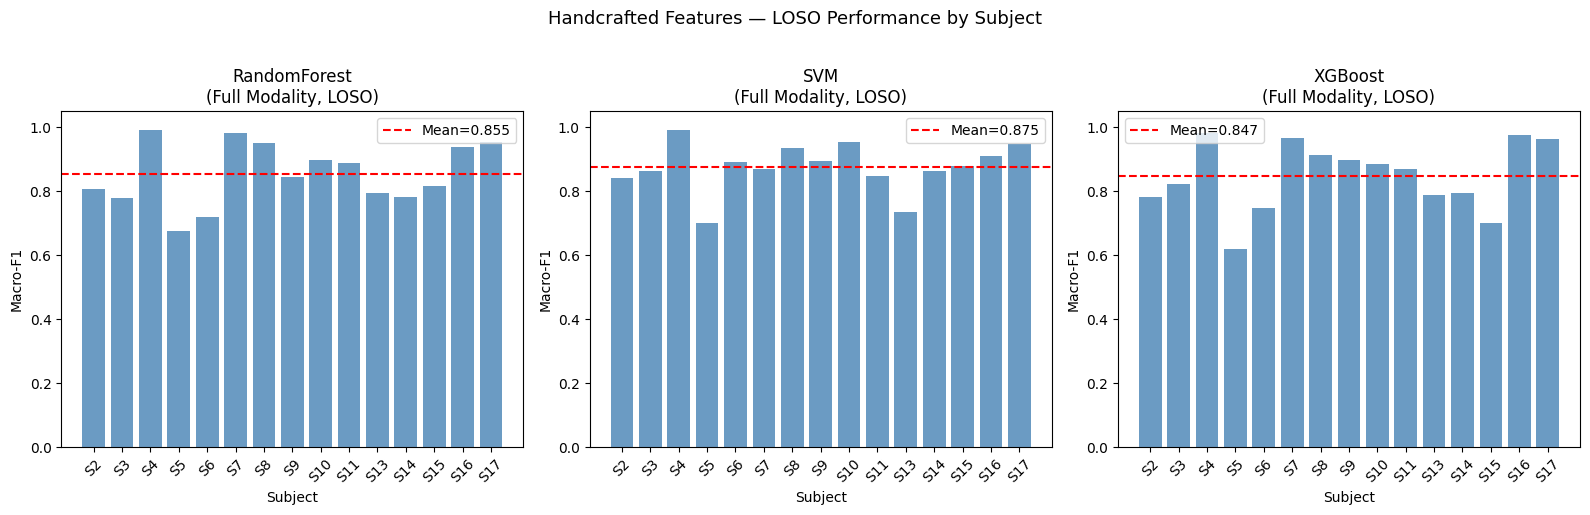

Saved figure.


In [ ]:
best_clf = max(all_results, key=lambda k: np.mean([r['macro_f1'] for r in all_results[k]]))
print(f"Best classifier: {best_clf}")
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, clf_name in zip(axes, all_results.keys()):
    results = all_results[clf_name]
    subjects = [r['subject'] for r in results]
    f1s      = [r['macro_f1'] for r in results]
    mean_f1  = np.mean(f1s)
    bars = ax.bar([f"S{s}" for s in subjects], f1s, color='steelblue', alpha=0.8)
    ax.axhline(mean_f1, color='red', linestyle='--', linewidth=1.5, label=f'Mean={mean_f1:.3f}')
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("Subject")
    ax.set_ylabel("Macro-F1")
    ax.set_title(f"{clf_name}\n(Full Modality, LOSO)")
    ax.legend()
    ax.tick_params(axis='x', rotation=45)

plt.suptitle("Handcrafted Features — LOSO Performance by Subject", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "handcrafted_loso_per_subject_f1.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved figure.")

In [ ]:
print("\n" + "="*55)
print("TABLE 1: Full Modality Performance (Handcrafted Features)")
print("="*55)
print(f"{'Model':<15} {'Accuracy':>10} {'Macro-F1':>10} {'AUROC':>10}")
print("-"*55)
for clf_name, results in all_results.items():
    acc   = np.mean([r['accuracy']  for r in results])
    f1    = np.mean([r['macro_f1']  for r in results])
    auroc = np.mean([r['auroc']     for r in results])
    acc_std   = np.std([r['accuracy']  for r in results])
    f1_std    = np.std([r['macro_f1']  for r in results])
    auroc_std = np.std([r['auroc']     for r in results])
    print(f"{clf_name:<15} {acc:.3f}±{acc_std:.3f}  {f1:.3f}±{f1_std:.3f}  {auroc:.3f}±{auroc_std:.3f}")
print("="*55)
print("(Values are mean ± std across 14 LOSO folds)")


TABLE 1: Full Modality Performance (Handcrafted Features)
Model             Accuracy   Macro-F1      AUROC
-------------------------------------------------------
RandomForest    0.881±0.074  0.855±0.095  0.957±0.057
SVM             0.895±0.061  0.875±0.074  0.972±0.026
XGBoost         0.882±0.071  0.847±0.105  0.972±0.028
(Values are mean ± std across 14 LOSO folds)


In [ ]:
print("\nPer-subject F1 for best classifier:")
for r in sorted(all_results[best_clf], key=lambda x: x['macro_f1']):
    flag = " ← LOW" if r['macro_f1'] < 0.65 else ""
    print(f"  S{r['subject']:2d}: F1={r['macro_f1']:.3f}{flag}")


Per-subject F1 for best classifier:
  S 5: F1=0.700
  S13: F1=0.735
  S 2: F1=0.843
  S11: F1=0.848
  S14: F1=0.861
  S 3: F1=0.862
  S 7: F1=0.871
  S15: F1=0.878
  S 6: F1=0.890
  S 9: F1=0.893
  S16: F1=0.910
  S 8: F1=0.936
  S17: F1=0.948
  S10: F1=0.955
  S 4: F1=0.992


In [ ]:
import pickle as pkl
MODELS_DIR = RESULTS_DIR / "models"
MODELS_DIR.mkdir(exist_ok=True)
best_clf_obj = get_classifiers()[best_clf]
print(f"Saving trained models and scalers for [{best_clf}] LOSO folds...")

import copy
for test_sid in tqdm(ALL_SUBJECTS):
    X_train, y_train, X_test, y_test, scaler = get_loso_split(test_sid)
    fold_clf = copy.deepcopy(best_clf_obj)
    fold_clf.fit(X_train, y_train)
    with open(MODELS_DIR / f"handcrafted_{best_clf}_test_S{test_sid}.pkl", 'wb') as f:
        pkl.dump(fold_clf, f)
    with open(MODELS_DIR / f"scaler_test_S{test_sid}.pkl", 'wb') as f:
        pkl.dump(scaler, f)

print("Done. Models and scalers saved.")
print(f"Location: {MODELS_DIR}")

Saving trained models and scalers for [SVM] LOSO folds...


100%|██████████| 15/15 [00:22<00:00,  1.51s/it]

Done. Models and scalers saved.
Location: ..\results\models


In [ ]:
from pathlib import Path
import json
import numpy as np

def build_experiment_config(
    best_classifier: str,
    all_results: dict,
    feature_slices: dict,
    n_features: int,
    all_subjects: list,
    modality_names: list,
    random_seed: int,
) -> dict:
    config = {
        "experiment": "handcrafted_full_modality",
        "best_classifier": best_classifier,
        "n_features": n_features,
        "feature_slices": {
            modality: {
                "start": sl.start,
                "stop": sl.stop
            }
            for modality, sl in feature_slices.items()
        },
        "subjects": all_subjects,
        "modality_names": modality_names,
        "random_seed": random_seed,
        "full_modality_results": {}
    }
    for clf_name, results in all_results.items():
        macro_f1 = np.array(
            [r["macro_f1"] for r in results],
            dtype=np.float64
        )
        auroc = np.array(
            [r["auroc"] for r in results],
            dtype=np.float64
        )
        config["full_modality_results"][clf_name] = {
            "mean_macro_f1": float(np.mean(macro_f1)),
            "std_macro_f1": float(np.std(macro_f1)),
            "mean_auroc": float(np.mean(auroc)),
            "std_auroc": float(np.std(auroc)),
            "per_subject_macro_f1": {
                f"S{r['subject']}": float(r["macro_f1"])
                for r in results
            },
        }
    return config

config = build_experiment_config(
    best_classifier=best_clf,
    all_results=all_results,
    feature_slices=FEATURE_SLICES,
    n_features=N_FEATURES,
    all_subjects=ALL_SUBJECTS,
    modality_names=MODALITY_NAMES,
    random_seed=RANDOM_SEED,
)
config_path = RESULTS_DIR / "handcrafted_config.json"

with open(config_path, "w", encoding="utf-8") as f:
    json.dump(config, f, indent=4)

print("\n" + "=" * 60)
print("Experiment configuration saved successfully.")
print(f"Location          : {config_path}")
print(f"Best classifier   : {config['best_classifier']}")
print(f"Feature count     : {config['n_features']}")
print(f"Modalities        : {', '.join(config['modality_names'])}")
print(f"Subjects          : {len(config['subjects'])}")
print("=" * 60)


Experiment configuration saved successfully.
Location          : ..\results\handcrafted_config.json
Best classifier   : SVM
Feature count     : 11
Modalities        : ECG, EDA, Respiration, Temperature
Subjects          : 15


In [ ]:
print("=== Pre-CNN Checklist ===\n")

checks = {
    "Feature .npy files exist for all subjects":
        all((FEATURES_DIR / f"S{sid}_features.npy").exists() for sid in ALL_SUBJECTS),
    "handcrafted_loso_full.json saved":
        (RESULTS_DIR / "handcrafted_loso_full.json").exists(),
    "handcrafted_loso_full.csv saved":
        (RESULTS_DIR / "handcrafted_loso_full.csv").exists(),
    "handcrafted_config.json saved":
        (RESULTS_DIR / "handcrafted_config.json").exists(),
    "Model .pkl files saved (should be 14)":
        len(list(MODELS_DIR.glob("handcrafted_*.pkl"))) == len(ALL_SUBJECTS),
    "Scaler .pkl files saved (should be 14)":
        len(list(MODELS_DIR.glob("scaler_*.pkl"))) == len(ALL_SUBJECTS),
    "No NaN in any feature file":
        all(not np.any(np.isnan(np.load(FEATURES_DIR / f"S{sid}_features.npy")))
            for sid in ALL_SUBJECTS),
}
all_pass = True
for check, passed in checks.items():
    status = "✓" if passed else "✗ FAIL"
    print(f"  [{status}] {check}")
    if not passed:
        all_pass = False
if all_pass:
    print("\n✓ All checks passed. Ready for CNN baseline.")
else:
    print("\n✗ Some checks failed. Fix before proceeding.")

=== Pre-CNN Checklist ===

  [✓] Feature .npy files exist for all subjects
  [✓] handcrafted_loso_full.json saved
  [✓] handcrafted_loso_full.csv saved
  [✓] handcrafted_config.json saved
  [✓] Model .pkl files saved (should be 14)
  [✓] Scaler .pkl files saved (should be 14)
  [✓] No NaN in any feature file

✓ All checks passed. Ready for CNN baseline.
